In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2 x_5 + x_4$

in: 5, out: 2

In [58]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [59]:
batch = 4
in_dim = 5
out_dim = 2

y_true = torch.tensor([[ -6., -28.],
                       [-21., -79.],
                       [36.,  138.],
                       [11.,  42.]]) # (batch, out_dim)
criterion = nn.MSELoss()

mask = torch.tensor([[0.9, -0.5], 
                     [-0.6, 0.6], 
                     [0.8, -0.5], 
                     [-0.9, -0.6],
                     [-0.6, 0.8]]).requires_grad_(True) # (in_dim, in_dim // 2)

x = torch.tensor([[2.0, 2.0, -2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0, -3.0, 3.0],
                  [4.0, -4.0, 4.0, 4.0, -4.0],
                  [4.0, -1.0, 2.0, 1.0, -2.0]]).requires_grad_(True) # (batch, in_dim)

y = some_func_to_add_dim(x, out_dim=out_dim) # (batch, in_dim, out_dim)

tau = 0.1
hard_mask = torch.sigmoid(mask / tau) # (in_dim, in_dim // 2)

# --- signs with threshold ---
# epsilon = 1e-8
# sign_data = torch.sign(y + epsilon) # (batch, in_dim, out_dim)
# mask_expanded = hard_mask[None, :, None, :] # (1, in_dim, 1, groups)
# sign_data_expanded = sign_data.unsqueeze(-1) # (batch, in_dim, out_dim, 1)
# selected_signs = torch.where(mask_expanded > 0.5, sign_data_expanded, 1.0) # (batch, in_dim, out_dim, in_dim // 2)
# final_sign = torch.prod(selected_signs, dim=1) # (batch, out_dim, in_dim // 2)
# masked_y_for_prod = torch.pow(torch.abs(y.unsqueeze(-1)), hard_mask[None, :, None, :]) # (batch, in_dim, out_dim, in_dim // 2)

# --- signs with linear representation ---
masked_y_for_prod = 1 - hard_mask[None, :, None, :] + hard_mask[None, :, None, :] * y.unsqueeze(-1) # (batch, in_dim, out_dim, in_dim // 2)
y_prod = torch.prod(masked_y_for_prod, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_sum = y * (1. - torch.sum(hard_mask, dim=1)[:, None]) # (batch, in_dim, out_dim)

y = torch.sum(masked_y_for_sum, dim=1) + torch.sum(y_prod, dim=2)

print("y.size() =", y.size())
print(y)
loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



y.size() = torch.Size([4, 2])
tensor([[ -5.9285, -27.7758],
        [-20.7027, -76.5018],
        [ 36.2673, 140.2303],
        [ 10.9046,  41.8166]], grad_fn=<AddBackward0>)
tensor([[ 1.2219e-03,  9.8583e+00],
        [-3.6339e+00,  6.6149e-01],
        [ 3.4755e-03,  2.8841e+01],
        [ 4.8847e-01,  1.0591e+01],
        [-1.0303e+01,  8.8898e-02]])


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [3]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
# y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
# y = x[:, 0] * x[:, 2] + x[:, 1]
# y_class = torch.where(y > 0.5, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

In [5]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-6  # для L1 активаций
    lamb_ent_acts = 1e-3  # для энтропии активаций

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            # for param_group in optimizer.param_groups:
            #     param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
                    
            new_tau = get_tau(epoch, epochs, tau_start=1.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            loss = train_loss + lamb_ent_ops * entropy_ops_avg # + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print(rounded_probs)
        

checkpoint directory created: ./model
saving model version 0.0


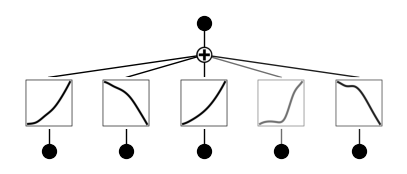

In [6]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [7]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

Epoch [10/1000], Train Loss: 0.3365, Test Loss: 0.3426
Epoch [20/1000], Train Loss: 0.2640, Test Loss: 0.3324
Epoch [30/1000], Train Loss: 0.2623, Test Loss: 0.3100
Epoch [40/1000], Train Loss: 0.2593, Test Loss: 0.3183
Epoch [50/1000], Train Loss: 0.2546, Test Loss: 0.3083
Epoch [60/1000], Train Loss: 0.2535, Test Loss: 0.3093
Epoch [70/1000], Train Loss: 0.2526, Test Loss: 0.3096
Epoch [80/1000], Train Loss: 0.2513, Test Loss: 0.3084
Epoch [90/1000], Train Loss: 0.2405, Test Loss: 0.2754
Epoch [100/1000], Train Loss: 0.1643, Test Loss: 0.1577
Epoch [110/1000], Train Loss: 0.0861, Test Loss: 0.0751
Epoch [120/1000], Train Loss: 0.0173, Test Loss: 0.0169
Epoch [130/1000], Train Loss: 0.0049, Test Loss: 0.0060
Epoch [140/1000], Train Loss: 0.0025, Test Loss: 0.0026
Epoch [150/1000], Train Loss: 0.0019, Test Loss: 0.0018
Epoch [160/1000], Train Loss: 0.0013, Test Loss: 0.0011
Epoch [170/1000], Train Loss: 0.0010, Test Loss: 0.0009
Epoch [180/1000], Train Loss: 0.0008, Test Loss: 0.0007
E

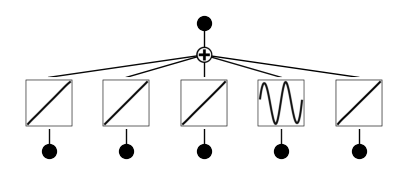

In [8]:
model.plot()

In [9]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-2.6926, -1.4475, -0.7535, -0.1538,  0.1687,  0.3169,  0.2777,
          -0.3553]],

        [[-2.3627, -1.5429, -0.8318, -0.2240,  0.2303,  0.5766,  0.7524,
           0.9939]],

        [[-2.9085, -2.1195, -1.0286, -0.2477,  0.2687,  0.5415,  0.5826,
           0.6745]],

        [[-4.7122,  0.7818,  0.6675, -1.6170,  1.6155, -0.6117, -0.6728,
           5.2031]],

        [[-3.6915, -1.9551, -1.1173, -0.2976,  0.3202,  0.7690,  1.0740,
           1.3496]]], device='cuda:0')
act_fun.0.scale_base tensor([[ 1.1087],
        [ 0.8517],
        [ 1.2441],
        [-0.2946],
        [ 1.3138]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.3959],
        [0.4947],
        [0.3726],
        [0.9387],
        [0.5990]], device='cuda:0')
act_fun.0.logits tensor([[[-0.2165,  4.3423, -1.1135]],

        [[-1.2799, -1.3790,  2.5355]],

        [[-0.3647,  4.0401, -1.2001]],

        [[ 4.0793, -0.7723, -1.1659]],

        [[ 4.5430, -0.5191, -1.0100]]], device='cuda:0'

In [10]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 0., 1.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


# **Dataset** $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

In [99]:
def get_tau(step, total_steps, tau_start=1.0, tau_end=0.1):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000, ops_update_freq=10):
    params_ops = []
    params_spline = []
    for module in model.modules():
        if isinstance(module, NexusKANLayer):
            if hasattr(module, 'logits'):
                params_ops.append(module.logits)
            # Параметры сплайнов
            params_spline.append(module.coef)
            params_spline.append(module.scale_base)
            params_spline.append(module.scale_sp)
    
    step_counter = 0
    
    # optimizer = optim.Adam(model.parameters(), lr=lr)
    optimizer_spline = optim.Adam(params_spline, lr=lr)
    optimizer_ops = optim.Adam(params_ops, lr=lr)
    criterion = nn.MSELoss()

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-1  # для L1 активаций
    lamb_ent_acts = 1e-1  # для энтропии активаций

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer_spline.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-3)
                    
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-3, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer_spline.zero_grad()
            optimizer_ops.zero_grad()
            loss.backward()
            optimizer_spline.step()  # сплайны обновляем всегда
            if step_counter % ops_update_freq == 0:
                optimizer_ops.step()  # операции обновляем реже
            # optimizer.zero_grad()
            # loss.backward()
            # optimizer.step()
            step_counter += 1
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print(rounded_probs)
            # for name, param in model.named_parameters():
            #     if param.requires_grad:
            #         print(name, param.data)

## **Test 1 :** $y = \frac{x_0}{x_1} + \frac{x_2}{x_3}$

In [100]:
end_range = 3.0
start_range = 1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


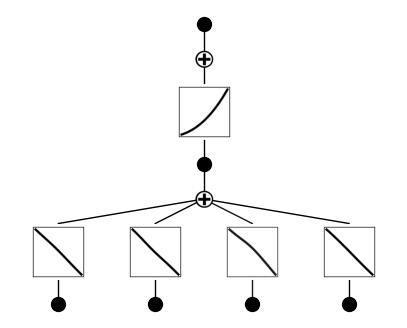

In [101]:
model = nexusKAN(width=[4, 1, 1], grid=5, k=3, seed=42, grid_range=[0.5, 4.0], device=device)
model(dataset['train_input'])
model.plot()

In [102]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

Epoch [10/1000], Train Loss: 0.5515, Test Loss: 0.5717
Epoch [20/1000], Train Loss: 0.3949, Test Loss: 0.4015
Epoch [30/1000], Train Loss: 0.0712, Test Loss: 0.0660
Epoch [40/1000], Train Loss: 0.0307, Test Loss: 0.0260
Epoch [50/1000], Train Loss: 0.0337, Test Loss: 0.0333
Epoch [60/1000], Train Loss: 0.0257, Test Loss: 0.0270
Epoch [70/1000], Train Loss: 0.0205, Test Loss: 0.0196
Epoch [80/1000], Train Loss: 0.0178, Test Loss: 0.0204
Epoch [90/1000], Train Loss: 0.0198, Test Loss: 0.0217
Epoch [100/1000], Train Loss: 0.0174, Test Loss: 0.0196
Epoch [110/1000], Train Loss: 0.0178, Test Loss: 0.0199
Epoch [120/1000], Train Loss: 0.0178, Test Loss: 0.0202
Epoch [130/1000], Train Loss: 0.0174, Test Loss: 0.0195
Epoch [140/1000], Train Loss: 0.0174, Test Loss: 0.0199
Epoch [150/1000], Train Loss: 0.0173, Test Loss: 0.0195
Epoch [160/1000], Train Loss: 0.0172, Test Loss: 0.0198
Epoch [170/1000], Train Loss: 0.0170, Test Loss: 0.0193
Epoch [180/1000], Train Loss: 0.0170, Test Loss: 0.0199
E

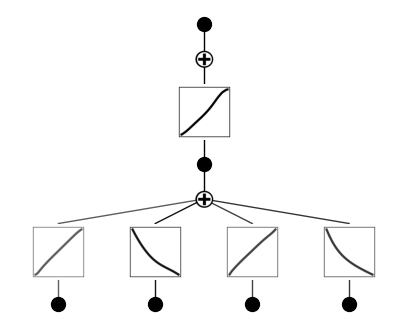

In [103]:
model.plot()

In [104]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[1., 0., 0.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 2 :** $y = \frac{x_0}{x_1}$

In [9]:
end_range = 3.0
start_range = 1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range

y = x[:, 0] / x[:, 1]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [17]:
model = nexusKAN(width=[2, 1, 1], grid=5, k=3, seed=42, grid_range=[0.5, 4.0], device=device)

checkpoint directory created: ./model
saving model version 0.0


In [18]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

Epoch [10/1000], Train Loss: 0.2818, Test Loss: 0.3017
Epoch [20/1000], Train Loss: 0.1676, Test Loss: 0.1412
Epoch [30/1000], Train Loss: 0.0585, Test Loss: 0.0458
Epoch [40/1000], Train Loss: 0.0307, Test Loss: 0.0214
Epoch [50/1000], Train Loss: 0.0128, Test Loss: 0.0085
Epoch [60/1000], Train Loss: 0.0065, Test Loss: 0.0041
Epoch [70/1000], Train Loss: 0.0038, Test Loss: 0.0029
Epoch [80/1000], Train Loss: 0.0029, Test Loss: 0.0022
Epoch [90/1000], Train Loss: 0.0022, Test Loss: 0.0015
Epoch [100/1000], Train Loss: 0.0017, Test Loss: 0.0012
Epoch [110/1000], Train Loss: 0.0014, Test Loss: 0.0010
Epoch [120/1000], Train Loss: 0.0012, Test Loss: 0.0008
Epoch [130/1000], Train Loss: 0.0010, Test Loss: 0.0007
Epoch [140/1000], Train Loss: 0.0009, Test Loss: 0.0006
Epoch [150/1000], Train Loss: 0.0008, Test Loss: 0.0005
Epoch [160/1000], Train Loss: 0.0007, Test Loss: 0.0004
Epoch [170/1000], Train Loss: 0.0006, Test Loss: 0.0003
Epoch [180/1000], Train Loss: 0.0005, Test Loss: 0.0003
E

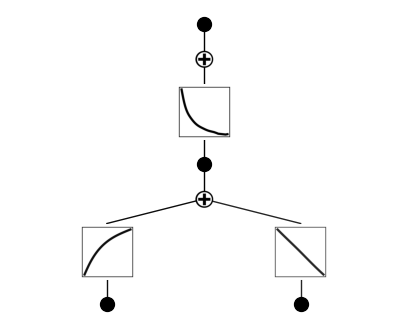

In [19]:
model.plot()

In [15]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[1., 0.]],

        [[1., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 3 :** $y = \frac{\frac{x_0}{x_1}}{\frac{x_2}{x_3}}$

In [4]:
end_range = 3.0
start_range = 1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] / x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [5]:
model = nexusKAN(width=[4, 2, 1], grid=5, k=3, seed=42, grid_range=[0.5, 4.0], device=device)

checkpoint directory created: ./model
saving model version 0.0


In [6]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

Epoch [2/1000], Train Loss: 0.0723, Test Loss: 0.0250
Epoch [4/1000], Train Loss: 0.0448, Test Loss: 0.0244
Epoch [6/1000], Train Loss: 0.0276, Test Loss: 0.0101
Epoch [8/1000], Train Loss: 0.0161, Test Loss: 0.0060
Epoch [10/1000], Train Loss: 0.0041, Test Loss: 0.0095
Epoch [12/1000], Train Loss: 0.0111, Test Loss: 0.0090
Epoch [14/1000], Train Loss: 0.0096, Test Loss: 0.0054
Epoch [16/1000], Train Loss: 0.0024, Test Loss: 0.0012
Epoch [18/1000], Train Loss: 0.0024, Test Loss: 0.0010
Epoch [20/1000], Train Loss: 0.0028, Test Loss: 0.0034
Epoch [22/1000], Train Loss: 0.0040, Test Loss: 0.0024
Epoch [24/1000], Train Loss: 0.0023, Test Loss: 0.0009
Epoch [26/1000], Train Loss: 0.0012, Test Loss: 0.0006
Epoch [28/1000], Train Loss: 0.0011, Test Loss: 0.0014
Epoch [30/1000], Train Loss: 0.0015, Test Loss: 0.0014
Epoch [32/1000], Train Loss: 0.0016, Test Loss: 0.0010
Epoch [34/1000], Train Loss: 0.0007, Test Loss: 0.0006
Epoch [36/1000], Train Loss: 0.0007, Test Loss: 0.0006
Epoch [38/1000

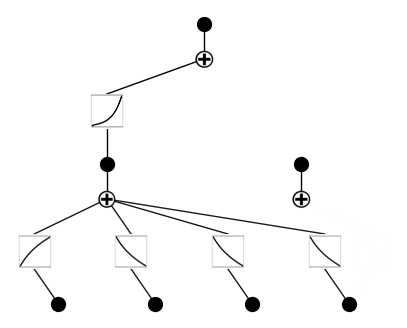

In [7]:
model.plot()

In [8]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 0., 1.],
         [1., 0., 0.]],

        [[0., 0., 1.],
         [0., 1., 0.]],

        [[0., 0., 1.],
         [0., 1., 0.]],

        [[0., 0., 1.],
         [1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0., 1.]],

        [[1., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$

In [92]:
end_range = 5.0
start_range = 1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


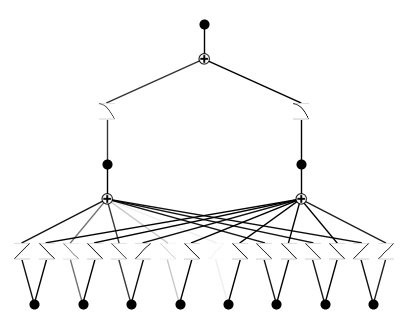

In [93]:
model = nexusKAN(width=[8, 2, 1], grid=5, k=3, seed=42, grid_range=[0.5, 6.0], device=device)
model(dataset['train_input'])
model.plot()

In [94]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

Epoch [2/1000], Train Loss: 1.3468, Test Loss: 1.1879
Epoch [4/1000], Train Loss: 0.9508, Test Loss: 0.8048
Epoch [6/1000], Train Loss: 0.8309, Test Loss: 0.8348
Epoch [8/1000], Train Loss: 0.8322, Test Loss: 0.6430
Epoch [10/1000], Train Loss: 0.6953, Test Loss: 0.5392
Epoch [12/1000], Train Loss: 0.5814, Test Loss: 0.4912
Epoch [14/1000], Train Loss: 0.4716, Test Loss: 0.5278
Epoch [16/1000], Train Loss: 0.4272, Test Loss: 0.4145
Epoch [18/1000], Train Loss: 0.4284, Test Loss: 0.3697
Epoch [20/1000], Train Loss: 0.3884, Test Loss: 0.3429
Epoch [22/1000], Train Loss: 0.3375, Test Loss: 0.2952
Epoch [24/1000], Train Loss: 0.2782, Test Loss: 0.2814
Epoch [26/1000], Train Loss: 0.2350, Test Loss: 0.2357
Epoch [28/1000], Train Loss: 0.2033, Test Loss: 0.2111
Epoch [30/1000], Train Loss: 0.1762, Test Loss: 0.1778
Epoch [32/1000], Train Loss: 0.1462, Test Loss: 0.1547
Epoch [34/1000], Train Loss: 0.1250, Test Loss: 0.1247
Epoch [36/1000], Train Loss: 0.1120, Test Loss: 0.1256
Epoch [38/1000

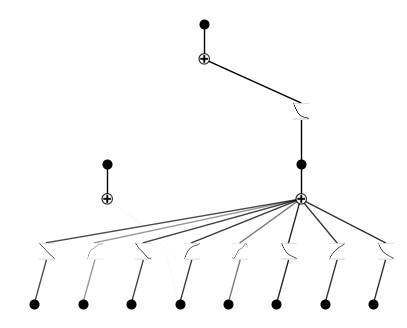

In [96]:
model.plot()

In [97]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1.]],

        [[0., 0., 0., 0., 1.],
         [0., 0., 0., 1., 0.]],

        [[0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.]],

        [[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.]],

        [[1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0.]],

        [[0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 1.]],

        [[0., 0., 0., 0., 1.],
         [1., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0.],
         [0., 0., 1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0., 1.]],

        [[0., 1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
